
## Stochastic gradient descent

The Gabor model has two parameters, so we could find the global minimum by either 

(i) exhaustively searching the parameter space or 
(ii) repeatedly starting gradient descent from different positions and choosing the result with the lowest loss. 

However, neural network models can have millions of parameters, so neither approach is practical. 

In short, using gradient descent to find the global optimum of a high-dimensional loss
function is challenging. <mark>We can find a minimum, but there is no way to tell whether this is the global minimum or even a good one.</mark>

<mark>One of the main problems is that the final destination of a gradient descent algorithm is entirely determined by the starting point</mark>. 

<mark>Stochastic gradient descent (SGD) attempts to remedy this problem by adding some noise to the gradient at each step</mark>. The solution still moves downhill on average, but at any given iteration, the direction chosen is not necessarily in the steepest downhill direction. 

Indeed, it might not be downhill at all. The SGD algorithm has the possibility of moving temporarily uphill and hence jumping from one “valley” of the loss function to another.

---

<img src="assets/Chap06/TrainGaborGDSGD.svg" style="filter: invert(1);" width="100%">

Gradient descent vs. stochastic gradient descent. 

a) Gradient descent with line search. As long as the gradient descent algorithm is initialized in the right “valley” of the loss function (e.g., points 1 and 3), the parameter estimate
will move steadily toward the global minimum. 

    However, if it is initialized outside this valley (e.g., point 2), it will descend toward one of the local minima. 

b) Stochastic gradient descent adds noise to the optimization process, so it is possible
to escape from the wrong valley (e.g., point 2) and still reach the global minimum.

---

<img src="assets/Chap06/TrainGaborSGDIter.svg" style="filter: invert(1);" width="100%">

Alternative view of SGD for the Gabor model with a batch size three.

a) Loss function for the entire training dataset. At each iteration, there is a probability
distribution of possible parameter changes (inset shows samples). These correspond to different choices of the three batch elements. 

b) Loss function for one possible batch. The SGD algorithm moves in the downhill direction on this
function for a distance that is determined by the learning rate and the local gradient magnitude. The current model (dashed function in inset) changes to better fit the batch data (solid function). 

c) <mark>A different batch creates a different loss function and results in a different update</mark>. 

d) <mark>For this batch, the algorithm moves downhill with respect to the batch loss function but in the locally uphill direction with respect to the global loss function in panel (a). This is how SGD can escape local minima</mark>.

---

### Batches and epochs

<mark>The mechanism for introducing randomness is simple. At each iteration, the algorithm
chooses a random subset of the training data and computes the gradient from these
examples alone. This subset is known as a minibatch or batch for short</mark>. 

The update rule for the model parameters $\phi_t$ at iteration $t$ is hence:

\begin{eqnarray}\label{eq:train_sgd}
  \boldsymbol\phi_{t+1}\longleftarrow\boldsymbol\phi_{t} - \alpha \cdot \sum_{i\in\mathcal{B}_{t}}\frac{\partial \ell_{i}[\boldsymbol\phi_{t}]}{\partial \boldsymbol\phi},
 \end{eqnarray}

where $\mathcal{B}_t$ is a set containing the indices of the input/output pairs in the current batch
and, as before, $ℓ_i$ is the loss due to the $i^{th}$ pair. The term $\alpha$ is the learning rate, and together with the gradient magnitude, determines the distance moved at each iteration.

The learning rate is chosen at the start of the procedure and does not depend on the
local properties of the function.

<mark>The batches are usually drawn from the dataset without replacement.</mark> 

The algorithm works through the training examples until it has used all the data, at which point it starts sampling from the full training dataset again. 

<mark>A single pass through the entire training dataset is referred to as an epoch</mark>. 

A batch may be as small as a single example or as large as the whole dataset. 

The latter case is called full-batch gradient descent and is identical to regular (non-stochastic) gradient descent.

An alternative interpretation of SGD is that it computes the gradient of a different
loss function at each iteration; the loss function depends on both the model and the
training data and hence will differ for each randomly selected batch. 

In this view, SGD performs deterministic gradient descent on a constantly changing loss function. However, despite this variability, the expected loss and expected gradients
at any point remain the same as for gradient descent.

### Properties of stochastic gradient descent


SGD has several attractive features. 

1. Although SGD adds noise to the trajectory, it still improves the fit to a subset of the data at each iteration. Hence, the updates tend to be sensible even if they are not optimal. 

2. Because it draws training examples without replacement and iterates through the dataset, the training examples all still contribute equally. 

3. It is less computationally expensive to compute the gradient from just a subset of the training data. 

4. It can (in principle) escape local minima.

5. It reduces the chances of getting stuck near saddle points; it is likely that at least
some of the possible batches will have a significant gradient at any point on the loss
function.

6. Finally, there is some evidence that SGD finds parameters for neural networks
that cause them to generalize well to new data in practice (see section 9.2).

SGD does not necessarily “converge” in the traditional sense. However, the hope is
that when we are close to the global minimum, all the data points will be well described
by the model. 

Consequently, the gradient will be small, whichever batch is chosen, and
the parameters will cease to change much. In practice, SGD is often applied with a
learning rate schedule. 

<mark>The learning rate $\alpha$ starts at a high value and is decreased by a constant factor every N epochs</mark>. 

The logic is that in the early stages of training, we want the algorithm to explore the parameter space, jumping from valley to valley to find a sensible region. 

In later stages, we are roughly in the right place and are more concerned with fine-tuning the parameters, so we decrease α to make smaller changes.


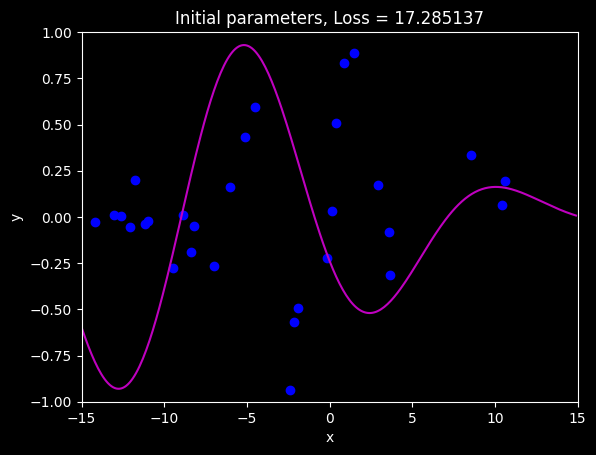

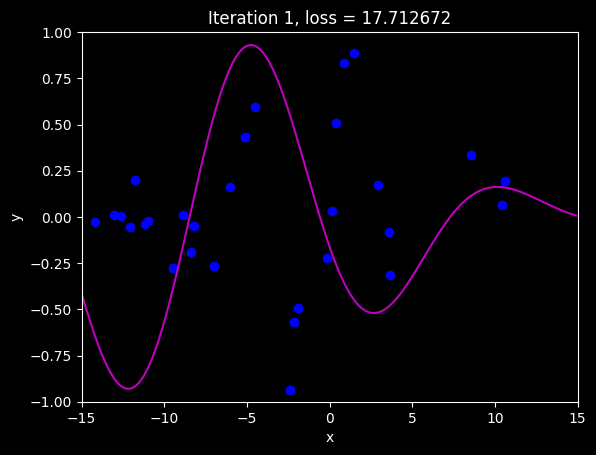

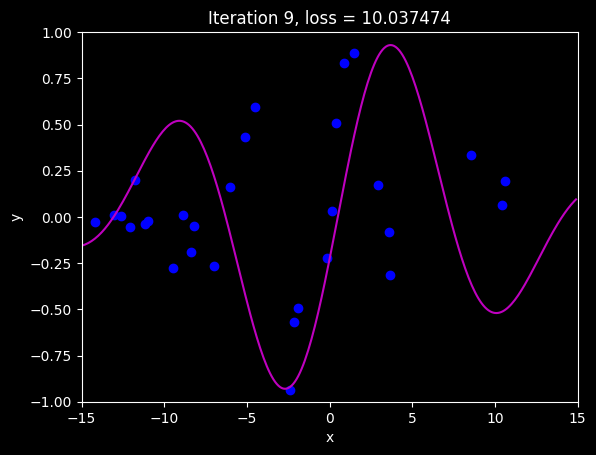

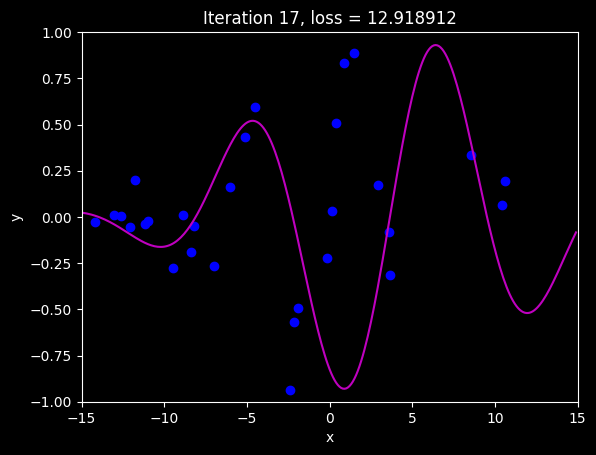

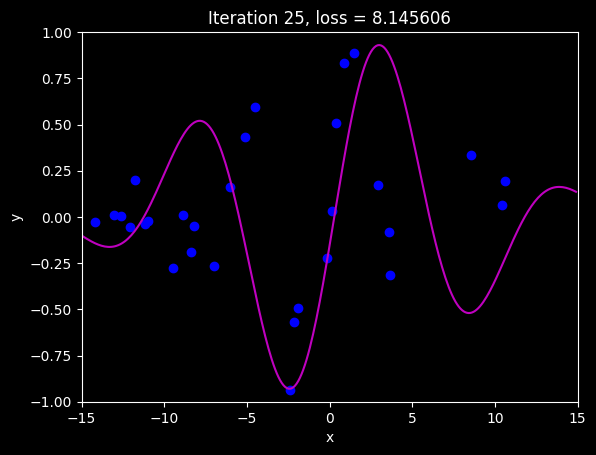

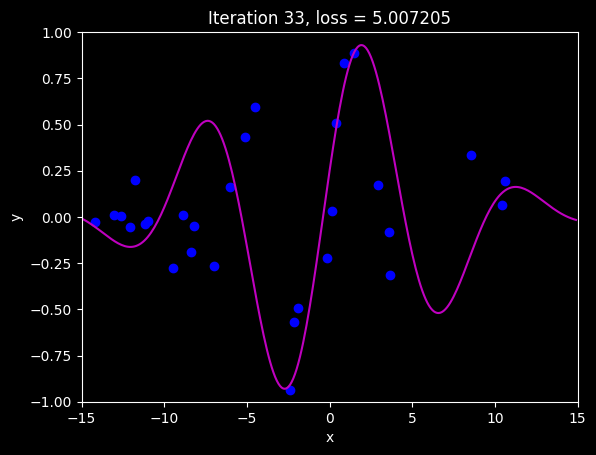

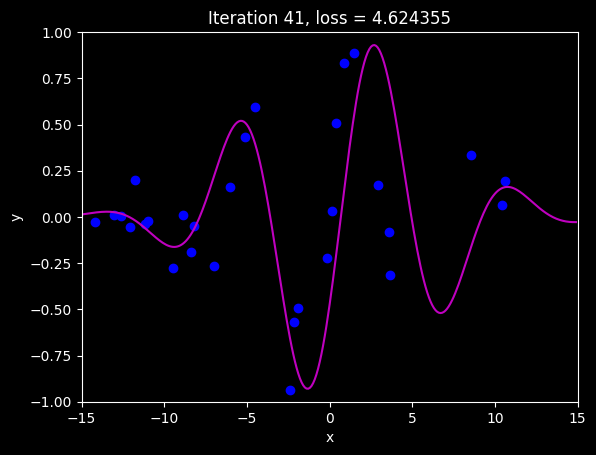

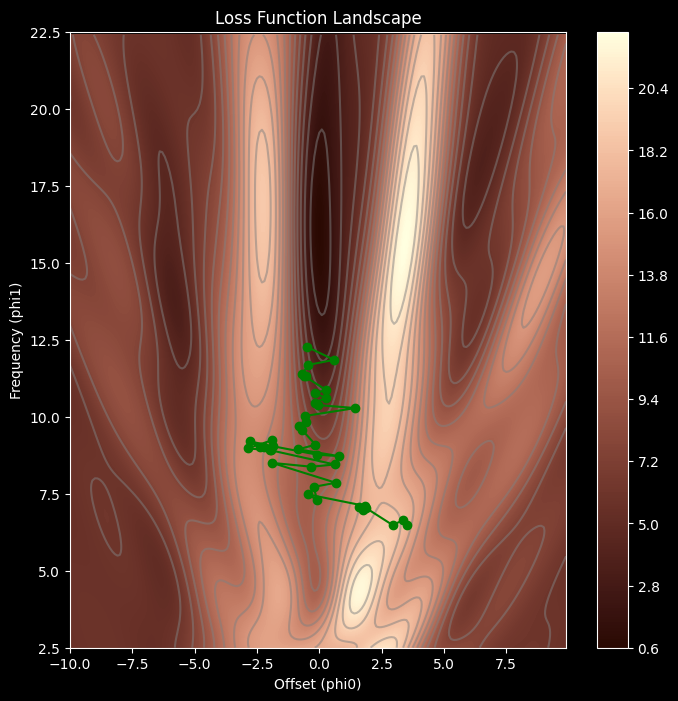

In [15]:
import numpy as np 
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap

plt.style.use('dark_background')

# Let's create our training data of 30 pairs {x_i, y_i}
# We'll try to fit the Gabor model to these data
data = np.array([[-1.920e+00,-1.422e+01,1.490e+00,-1.940e+00,-2.389e+00,-5.090e+00, -8.861e+00,3.578e+00,-6.010e+00,-6.995e+00,3.634e+00,8.743e-01, -1.096e+01,4.073e-01,-9.467e+00,8.560e+00,1.062e+01,-1.729e-01, 1.040e+01,-1.261e+01,1.574e-01,-1.304e+01,-2.156e+00,-1.210e+01, -1.119e+01,2.902e+00,-8.220e+00,-1.179e+01,-8.391e+00,-4.505e+00],
                  [-1.051e+00,-2.482e-02,8.896e-01,-4.943e-01,-9.371e-01,4.306e-01, 9.577e-03,-7.944e-02 ,1.624e-01,-2.682e-01,-3.129e-01,8.303e-01, -2.365e-02,5.098e-01,-2.777e-01,3.367e-01,1.927e-01,-2.222e-01, 6.352e-02,6.888e-03,3.224e-02,1.091e-02,-5.706e-01,-5.258e-02, -3.666e-02,1.709e-01,-4.805e-02,2.008e-01,-1.904e-01,5.952e-01]])

def compute_loss(data_x, data_y, model, phi):
  y_pred = model(phi,data_x)
  loss = np.sum((y_pred - data_y)**2)
  return loss

def gabor_deriv_phi0(data_x,data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = cos_component * gauss_component - sin_component * gauss_component * x / 16
    deriv = 2* deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Define pretty colormap
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Make grid of offset/frequency values to plot
  offsets_mesh, freqs_mesh = np.meshgrid(np.arange(-10,10.0,0.1), np.arange(2.5,22.5,0.1))
  loss_mesh = np.zeros_like(freqs_mesh)
  # Compute loss for every set of parameters
  for idslope, slope in np.ndenumerate(freqs_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[offsets_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  a = ax.contourf(offsets_mesh,freqs_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(offsets_mesh,freqs_mesh,loss_mesh,20,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([2.5,22.5])
  ax.set_xlabel('Offset (phi0)'); ax.set_ylabel('Frequency (phi1)')
  fig.colorbar(a)
  ax.set_title('Loss Function Landscape')
  plt.show()

def gabor_deriv_phi1(data_x, data_y,phi0, phi1):
    x = 0.06 * phi1 * data_x + phi0
    y = data_y
    cos_component = np.cos(x)
    sin_component = np.sin(x)
    gauss_component = np.exp(-0.5 * x *x / 16)
    deriv = 0.06 * data_x * cos_component * gauss_component - 0.06 * data_x*sin_component * gauss_component * x / 16
    deriv = 2*deriv * (sin_component * gauss_component - y)
    return np.sum(deriv)

def compute_gradient(data_x, data_y, phi):
    dl_dphi0 = gabor_deriv_phi0(data_x, data_y, phi[0],phi[1])
    dl_dphi1 = gabor_deriv_phi1(data_x, data_y, phi[0],phi[1])
    # Return the gradient
    return np.array([[dl_dphi0],[dl_dphi1]])

def gradient_descent_step_fixed_learning_rate(phi, data, alpha):
  grad = compute_gradient(data[0,:], data[1,:], phi)
  phi = phi - alpha * grad
  return phi

# Draw model
def draw_model(data,model,phi,title=None):
  x_model = np.arange(-15,15,0.1)
  y_model = model(phi,x_model)

  fix, ax = plt.subplots()
  ax.plot(data[0,:],data[1,:],'bo')
  ax.plot(x_model,y_model,'m-')
  ax.set_xlim([-15,15]);ax.set_ylim([-1,1])
  ax.set_xlabel('x'); ax.set_ylabel('y')
  if title is not None:
    ax.set_title(title)
  plt.show()

# Let's define our model
def model(phi,x):
  sin_component = np.sin(phi[0] + 0.06 * phi[1] * x)
  gauss_component = np.exp(-(phi[0] + 0.06 * phi[1] * x) * (phi[0] + 0.06 * phi[1] * x) / 32)
  y_pred= sin_component * gauss_component
  return y_pred     

def stochastic_gradient_descent_step(phi, data, alpha, batch_size):
  n_data = data.shape[1]
  indices = np.random.permutation(n_data)[:batch_size]
  grad = compute_gradient(data[0,indices], data[1,indices], phi)
  phi = phi - alpha * grad
  return phi

# Set the random number generator so you always get same numbers (disable if you don't want this)
np.random.seed(1)
# Initialize the parameters
n_steps = 41
phi_all = np.zeros((2,n_steps+1))
phi_all[0,0] = 3.5
phi_all[1,0] = 6.5

# Measure loss and draw initial model
loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  # Do gradient descent step
  phi_all[:,c_step+1:c_step+2] = stochastic_gradient_descent_step(phi_all[:,c_step:c_step+1],data, alpha =0.8, batch_size=5)
  # Measure loss and draw model every 8th step
  if c_step % 8 == 0:
    loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
    draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all)
     